In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parents[3]))
from utils.helpers import load_data

In [34]:
# Define consistent color palette for the entire analysis
COLOR_COMBINED = '#6B8CAE'    # Steel blue for combined data
COLOR_MALE = '#4A90E2'        # Bright blue for male students
COLOR_FEMALE = '#E85A9B'      # Pink for female students
COLOR_BOXPLOT = '#2C3E50'     # Dark blue-grey for boxplots

# Gender color mapping for easy reference
GENDER_COLORS = {
    'M': COLOR_MALE,
    'F': COLOR_FEMALE,
    'Male': COLOR_MALE,
    'Female': COLOR_FEMALE,
    'Combined': COLOR_COMBINED
}

# Detailed analysis of time during the exam. expexted time vs. time taken task by task + by gender. see if time taken by task affects performance during each task.

In this part we performe the analysis only on students without extra or incident time.

## 1. Data Loading

In [35]:
df = load_data("../data/cleaned_data/IN1020_2024_cleaned_data.csv")
df.head()

Data loaded successfully from ../data/cleaned_data/IN1020_2024_cleaned_data.csv


,exam_start_time,exam_end_time,extra_time_mins,incident_time_mins,gender,student_id,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,candidate_response_code,candidate_response_text,total_score
0,2024-12-11 14:00:02,2024-12-11 15:57:52,0,0,M,418,2.4,1.1,Tallsystemer,85,2.4,simpleChoice_1368096164456,Heksadesimale tall,71.61
1,2024-12-11 14:00:02,2024-12-11 15:57:52,0,0,M,418,2.4,1.1,Tallsystemer,85,2.4,simpleChoice_IA172399520449584402464-f255-46e6...,Oktale tall,71.61
2,2024-12-11 14:00:02,2024-12-11 15:57:52,0,0,M,418,2.4,1.1,Tallsystemer,85,2.4,simpleChoice_IA17239952044953d28e157-ac4c-49db...,Titallsystemet,71.61
3,2024-12-11 14:00:02,2024-12-11 15:57:52,0,0,M,418,2.4,1.1,Tallsystemer,85,2.4,simpleChoice_IA1723995204495960f601e-73d5-48f8...,Heksadesimale tall,71.61
4,2024-12-11 14:00:02,2024-12-11 15:57:52,0,0,M,418,2.4,1.1,Tallsystemer,85,2.4,simpleChoice_IA17239952636882cb13f25-bd73-4352...,Titallsystemet,71.61


## 2. Data Preparation

In [36]:
df_time = df.groupby(['student_id', 'question_number']).agg({
    'gender': 'first',
    'max_question_score': 'first',
    'auto_score_per_question': 'first',
    'question_duration_sec': 'first',
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'extra_time_mins': 'first',
    'incident_time_mins': 'first',
    'total_score': 'first'
}).reset_index()

df_time['time_taken_exam_min'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)
df_time = df_time.drop(columns=['exam_start_time', 'exam_end_time'])

df_time['expected_time_per_question_sec'] = 144 * df_time['max_question_score']  # Assuming 144 sec (2.4 minutes) per point since total exam time is 240 minutes for 100 points

df_time.head()

,student_id,question_number,gender,max_question_score,auto_score_per_question,question_duration_sec,extra_time_mins,incident_time_mins,total_score,time_taken_exam_min,expected_time_per_question_sec
0,1,1.1,M,2.4,2.4,52,0,0,72.63,136.97,345.6
1,1,1.2,M,3.0,3.0,105,0,0,72.63,136.97,432.0
2,1,1.3,M,3.8,0.0,328,0,0,72.63,136.97,547.2
3,1,1.4,M,3.0,3.0,118,0,0,72.63,136.97,432.0
4,1,1.5,M,3.0,3.0,69,0,0,72.63,136.97,432.0


## 3. Data exploration

In [37]:
extra_time_students_data = df_time[(df_time['extra_time_mins'] != 0) | (df_time['incident_time_mins'] != 0)]

extra_time_students_count = extra_time_students_data.groupby('student_id').agg({
    'extra_time_mins': 'first',
    'incident_time_mins': 'first'
}).reset_index()

counter1 = 0
counter2 = 0

for i in extra_time_students_count['extra_time_mins']:
    if i != 0:
        counter1 += 1

for i in extra_time_students_count['incident_time_mins']:
    if i != 0:
        counter2 += 1

print(f"There are {counter1} students with extra_time_mins (given before the exam).")
print(f"There are {counter2} students with incident_time_mins (given during the exam).")

There are 53 students with extra_time_mins (given before the exam).
There are 6 students with incident_time_mins (given during the exam).


In [38]:
# remove students with extra time or incident time
df_time = df_time[(df_time['extra_time_mins'] == 0) & (df_time['incident_time_mins'] == 0)]

In [39]:
# checking
print("After filtering:")
print(f"Students with extra_time_mins != 0: {len(df_time[df_time['extra_time_mins'] != 0])}")
print(f"Students with incident_time_mins != 0: {len(df_time[df_time['incident_time_mins'] != 0])}")
print(f"Total students remaining: {df_time['student_id'].nunique()}")

After filtering:
Students with extra_time_mins != 0: 0
Students with incident_time_mins != 0: 0
Total students remaining: 513


In [40]:
# description and exploration of spesific columns in df_time
df_time[['time_taken_exam_min']].describe()

,time_taken_exam_min
count,15390.000000
mean,197.775536
std,43.918686
min,40.750000
25%,169.580000
50%,211.730000
75%,237.220000
max,240.770000


=== TIME OUTLIER ANALYSIS ===
Combined Time: 90 outliers (0.6%)
  Range: 40.75 - 57.28
Male Time: 30 outliers (0.3%)
  Range: 40.75 - 40.75
Female Time: 180 outliers (2.6%)
  Range: 81.93 - 117.35


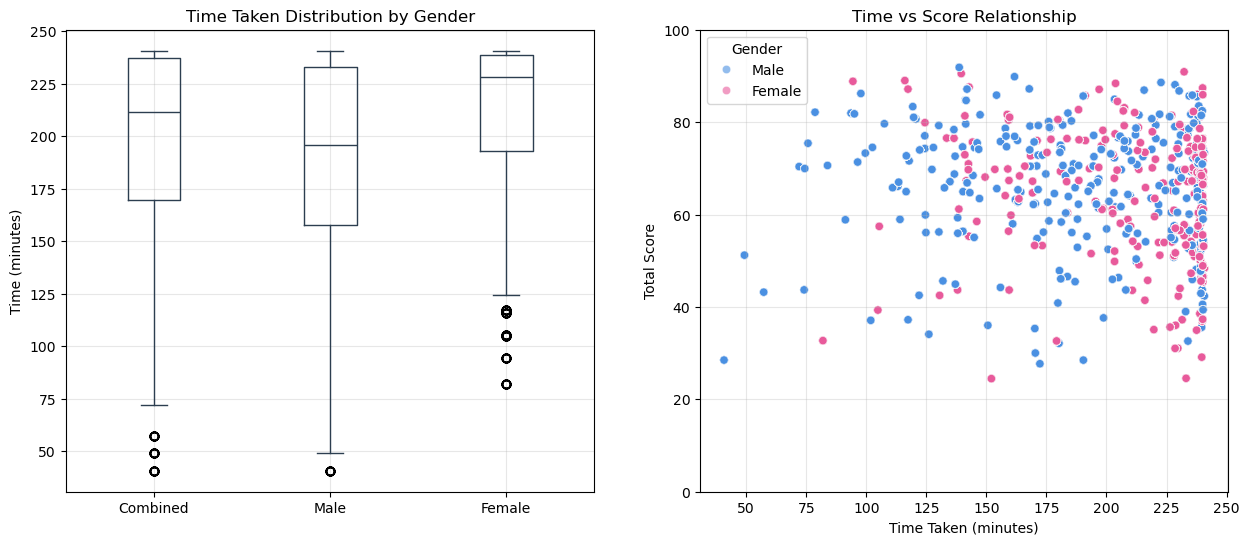

<Figure size 640x480 with 0 Axes>

In [41]:
# Enhanced time analysis visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Time taken boxplot
df_time_outliers = pd.DataFrame({
    'Combined': df_time['time_taken_exam_min'],
    'Male': df_time[df_time['gender'] == 'M']['time_taken_exam_min'],
    'Female': df_time[df_time['gender'] == 'F']['time_taken_exam_min']
})

df_time_outliers.boxplot(ax=axes[0], return_type='dict', color=COLOR_BOXPLOT)
axes[0].set_title("Time Taken Distribution by Gender")
axes[0].set_ylabel("Time (minutes)")
axes[0].grid(True, alpha=0.3)

# Identify outliers using IQR method
def identify_outliers(data, name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"{name}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Range: {outliers.min():.2f} - {outliers.max():.2f}")
    return outliers

# Time outlier analysis
print("=== TIME OUTLIER ANALYSIS ===")
time_combined_outliers = identify_outliers(df_time['time_taken_exam_min'], "Combined Time")
time_male_outliers = identify_outliers(df_time[df_time['gender'] == 'M']['time_taken_exam_min'], "Male Time")
time_female_outliers = identify_outliers(df_time[df_time['gender'] == 'F']['time_taken_exam_min'], "Female Time")

# Time vs Score relationship
sns.scatterplot(data=df_time, x='time_taken_exam_min', y='total_score', 
               hue='gender', alpha=0.6, ax=axes[1],
               palette={'F': COLOR_FEMALE, 'M': COLOR_MALE})
axes[1].set_title("Time vs Score Relationship")
axes[1].set_xlabel("Time Taken (minutes)")
axes[1].set_ylabel("Total Score")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)

# Update legend labels for clarity - map the original labels to proper gender names
handles, labels = axes[1].get_legend_handles_labels()
# Create a mapping from the original labels (F/M) to full names
label_mapping = {'F': 'Female', 'M': 'Male'}
new_labels = [label_mapping.get(label, label) for label in labels]
axes[1].legend(handles, new_labels, title='Gender')

plt.show()
plt.tight_layout()

In [42]:
# description and exploration of spesific columns in df_time
df_time[['expected_time_per_question_sec', 'question_duration_sec']].describe()

,expected_time_per_question_sec,question_duration_sec
count,15390.000000,15390.000000
mean,480.000000,384.518129
std,164.834867,370.490344
min,144.000000,0.000000
25%,432.000000,145.000000
50%,432.000000,276.000000
75%,576.000000,501.000000
max,864.000000,7545.000000


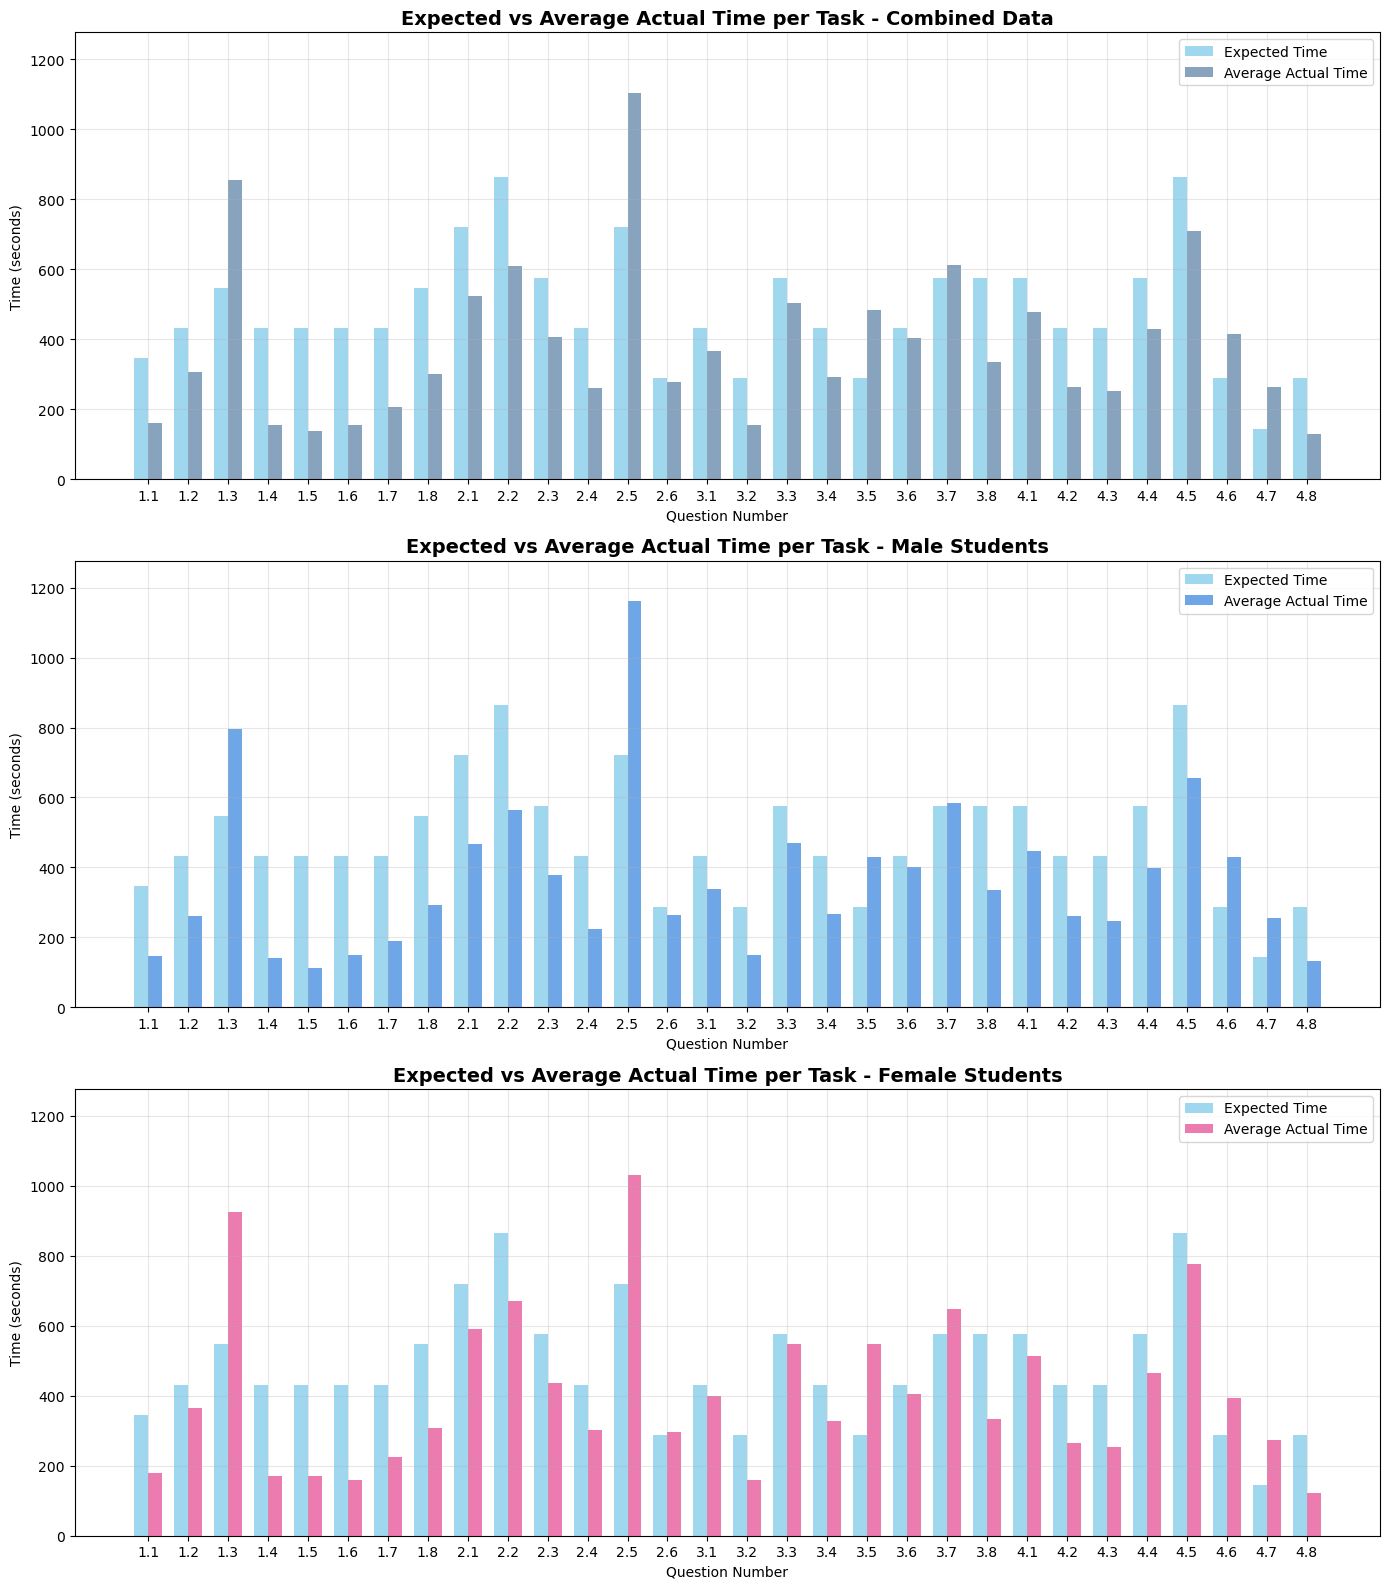

In [43]:
# Bar plots comparing expected vs actual time per task
# Calculate average time per question for each group
time_by_task = df_time.groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',  # Same for all students
    'question_duration_sec': 'mean'  # Average actual time
}).reset_index()

time_by_task_male = df_time[df_time['gender'] == 'M'].groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',
    'question_duration_sec': 'mean'
}).reset_index()

time_by_task_female = df_time[df_time['gender'] == 'F'].groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',
    'question_duration_sec': 'mean'
}).reset_index()

# Determine the maximum y-axis value for consistent scaling across all plots
max_expected = max(time_by_task['expected_time_per_question_sec'].max(),
                   time_by_task_male['expected_time_per_question_sec'].max(),
                   time_by_task_female['expected_time_per_question_sec'].max())
max_actual = max(time_by_task['question_duration_sec'].max(),
                 time_by_task_male['question_duration_sec'].max(),
                 time_by_task_female['question_duration_sec'].max())
y_max = max(max_expected, max_actual) * 1.1  # Add 10% padding

# Create the three plots
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Plot 1: Combined data
x = time_by_task['question_number']
width = 0.35
x_pos = range(len(x))

bars1 = axes[0].bar([i - width/2 for i in x_pos], time_by_task['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x_pos], time_by_task['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_COMBINED, alpha=0.8)

axes[0].set_xlabel('Question Number')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Expected vs Average Actual Time per Task - Combined Data', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x)
axes[0].set_ylim(0, y_max)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add value labels on bars
# for bar in bars1:
#     height = bar.get_height()
#     axes[0].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)
# for bar in bars2:
#     height = bar.get_height()
#     axes[0].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

# Plot 2: Male students
x_male = time_by_task_male['question_number']
x_pos_male = range(len(x_male))

bars3 = axes[1].bar([i - width/2 for i in x_pos_male], time_by_task_male['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars4 = axes[1].bar([i + width/2 for i in x_pos_male], time_by_task_male['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_MALE, alpha=0.8)

axes[1].set_xlabel('Question Number')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Expected vs Average Actual Time per Task - Male Students', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos_male)
axes[1].set_xticklabels(x_male)
axes[1].set_ylim(0, y_max)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add value labels on bars
# for bar in bars3:
#     height = bar.get_height()
#     axes[1].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)
# for bar in bars4:
#     height = bar.get_height()
#     axes[1].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

# Plot 3: Female students
x_female = time_by_task_female['question_number']
x_pos_female = range(len(x_female))

bars5 = axes[2].bar([i - width/2 for i in x_pos_female], time_by_task_female['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars6 = axes[2].bar([i + width/2 for i in x_pos_female], time_by_task_female['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_FEMALE, alpha=0.8)

axes[2].set_xlabel('Question Number')
axes[2].set_ylabel('Time (seconds)')
axes[2].set_title('Expected vs Average Actual Time per Task - Female Students', fontsize=14, fontweight='bold')
axes[2].set_xticks(x_pos_female)
axes[2].set_xticklabels(x_female)
axes[2].set_ylim(0, y_max)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Add value labels on bars
# for bar in bars5:
#     height = bar.get_height()
#     axes[2].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)
# for bar in bars6:
#     height = bar.get_height()
#     axes[2].text(bar.get_x() + bar.get_width()/2., height + 10,
#                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()